# E2-B: a second fresh sample of long logic sentences — gold-free NL→FOL faithfulness scoring

This notebook demos **E2-B** (iteration 5, experiment 12). E2-B is a pre-registered replication sample for one gold-free metric for
natural-language → first-order-logic (NL→FOL) output: **frozen cross-family consensus `V0 = c_score_align`**.
It compares that metric with an LLM judge (gemini flash-lite, reading a *disguised* nonce-word version of the text and formula).

**The setup**
- **Sample:** 400 untouched MALLS-train sentences with ≥ 25 words and ≥ 3 conditions (the "L25" stratum).
- **Candidates:** 10 frozen generator slots from 9 model families formalise each sentence (4,000 candidates).
- **Score:** each candidate is scored by how much it *disagrees* with the formalisations from the *other* families.
  z3 checks equivalence after predicate alignment, so a higher `V0` means the candidate is more likely an ERROR.
  No gold formula is used.
- **Labels:** E2's frozen solver pipeline compares each candidate with the MALLS gold. The blind panel never ran, because the
  run-level API budget ran out. So the only testable population is **R_A_UNAUDITED**: CORRECT means z3-equivalent to the
  *unaudited* MALLS gold. All label-based numbers are therefore **EXPLORATORY**, not a faithfulness test.

**What the original `method.py` does:** it orchestrates the pipeline stages: select → generate → label → score → judges →
finalize → rederive. Most stages need paid OpenRouter calls and several pinned virtual environments, so they cannot run in Colab.
This notebook therefore:
1. shows the `method.py` orchestrator as it is, with execution switched off by default;
2. runs the stage that *can* run anywhere, **`rederive`** (`src/rederive_headline.py`). It independently re-derives every
   headline number from the sealed labels and sealed scores: stratified AUROC of V0 and of the flash-lite judge, their paired
   delta with a sentence-cluster bootstrap CI, two placebos that must fail, the label-coupling diagnostic (V0 recomputed from
   the raw z3 pairwise-equivalence matrix without gold-equivalent peers), label-free concordance, and rename-invariance flips.

The input is a 100-sentence subset (`mini_demo_data.json`). It includes all 31 sentences that have a CORRECT row, each with its
10 candidates, labels, scores, z3 equivalence matrix and rename controls. The numbers will be close to, but not identical to,
the full-run values, which are shown next to them at the end.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No packages outside Colab's pre-installed set are needed.
# numpy, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

In [2]:
# --- original imports of method.py ---
from __future__ import annotations

import argparse
import subprocess
import sys
from pathlib import Path

# --- original imports of src/rederive_headline.py ---
import json
from collections import defaultdict

import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

# --- added for the notebook ---
import time
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_e4aqYfQhdCkX/round-5/experiment-12/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(data["metadata"]["description"])
print("sentences loaded:", len(examples), "| candidates:", sum(len(e["candidates"]) for e in examples))

100 of the 400 E2-B sentences (all 31 sentences with an R_A_UNAUDITED CORRECT row first), each with its 10 generator candidates, sealed labels, sealed label-free scores (V0 c_score_align, flash-lite disguised judge), the eval-2 z3 pairwise-equivalence matrix and rename controls.
sentences loaded: 100 | candidates: 1000


## Configuration

All tunable parameters are here. Each value's original setting is noted in its comment.
`N_SENTENCES` limits how many of the 100 demo sentences are used. The full run used all 400 sentences, which are not in the demo file.

In [5]:
B_BOOT = 2000        # sentence-cluster bootstrap resamples for the V0 - flash-lite delta CI (original: 2000)
N_PERM = 200        # within-word-bin label permutations for the placebo null (original: 200)
B_PLACEBO = 1000     # bootstrap resamples for the two placebo CIs (original: 1000)
N_SENTENCES = 100    # demo sentences used (max 100 in mini_demo_data.json; the full run had 400)
RUN_PIPELINE = False  # True would call the original paid/venv-dependent stages of method.py (not runnable in Colab)

## 1. The original entry point (`method.py`)

`method.py` runs each pre-registered stage as a subprocess in its own pinned environment:
- `e2bsrc/.venv` is E2's frozen labelling pipeline;
- `exp5src/.venv` is exp-5's byte-identical V0 scoring code.

Paid stages (`generate`, `labels`, `judges`) are cached and resumable. The code below is unchanged except for two things:
`WS` points at the current directory, and nothing is executed unless `RUN_PIPELINE = True`. With the flag off, the cell only
prints the stage plan. The stage this notebook actually reproduces is **`rederive`**, in the sections that follow.

In [6]:
WS = Path.cwd()  # original: Path(__file__).resolve().parent
EPY = str(WS / "e2bsrc/.venv/bin/python")
SPY = str(WS / "exp5src/.venv/bin/python")
STAGES = {
    "freeze_check": [[EPY, "src_e2b/code_freeze_check.py"], "e2bsrc"],
    "select": [[EPY, "src_e2b/select_e2b.py"], "e2bsrc"],
    "prereg": [["python3", "src/prereg_e2b.py"], "."],  # refuses to overwrite the frozen prereg
    "generate": [["bash", "e2bsrc/src_e2b/gen_all.sh"], "."],
    "labels": [["bash", "e2bsrc/src_e2b/run_batches_resume.sh"], "."],
    "score": [["bash", "-c", "bash src/scoring_pipeline.sh && bash src/cpu_chain.sh"], "."],
    "judges": [["bash", "src/judge_resume.sh"], "."],
    "finalize": [["bash", "src/finalize.sh"], "."],
    "rederive": [[SPY, "src/rederive_headline.py"], "."],
}


def run(name: str) -> int:
    cmd, cwd = STAGES[name]
    print(f"=== stage {name}: {' '.join(cmd)} (cwd {cwd})", flush=True)
    return subprocess.run(cmd, cwd=str(WS / cwd)).returncode


def main() -> int:
    ap = argparse.ArgumentParser()
    ap.add_argument("--stage", default="all", choices=["all", *STAGES])
    a = ap.parse_args([])  # original: ap.parse_args() (no CLI in a notebook)
    names = [n for n in STAGES if n != "prereg"] if a.stage == "all" else [a.stage]
    for n in names:
        rc = run(n)
        if rc != 0:
            print(f"stage {n} failed (rc {rc})")
            return rc
    return 0


if RUN_PIPELINE:
    main()
else:
    for n, (cmd, cwd) in STAGES.items():
        print(f"stage {n:<12} -> {' '.join(c.replace(str(WS) + '/', '') for c in cmd)}  (cwd {cwd})")  # plan only, paths relative to WS

stage freeze_check -> e2bsrc/.venv/bin/python src_e2b/code_freeze_check.py  (cwd e2bsrc)
stage select       -> e2bsrc/.venv/bin/python src_e2b/select_e2b.py  (cwd e2bsrc)
stage prereg       -> python3 src/prereg_e2b.py  (cwd .)
stage generate     -> bash e2bsrc/src_e2b/gen_all.sh  (cwd .)
stage labels       -> bash e2bsrc/src_e2b/run_batches_resume.sh  (cwd .)
stage score        -> bash -c bash src/scoring_pipeline.sh && bash src/cpu_chain.sh  (cwd .)
stage judges       -> bash src/judge_resume.sh  (cwd .)
stage finalize     -> bash src/finalize.sh  (cwd .)
stage rederive     -> exp5src/.venv/bin/python src/rederive_headline.py  (cwd .)


## 2. Statistics helpers (from `src/rederive_headline.py`, unchanged)

- `strat_auc` is the **word-bin-stratified AUROC**: a per-bin `roc_auc_score`, weighted by n_ERROR × n_CORRECT. "Positive" is
  ERROR, so a good error detector scores > 0.5. Stratifying stops sentence length from confounding the metric.
- `boot_delta` gives a **sentence-cluster bootstrap** CI for the difference of two stratified AUROCs. It resamples whole
  sentences, because the 10 candidates of one sentence are not independent.

In [7]:
def jl(p):
    return [json.loads(l) for l in Path(p).read_text().splitlines() if l.strip()]


def strat_auc(y, s, h):
    num = den = 0.0
    for b in set(h):
        m = h == b
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += roc_auc_score(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


def boot_delta(y, a, b, h, sid, B=2000, seed=12345):
    rng = np.random.default_rng(seed)
    idx_by = defaultdict(list)
    for i, s in enumerate(sid):
        idx_by[s].append(i)
    keys = list(idx_by)
    out = []
    for _ in range(B):
        ix = np.concatenate([idx_by[keys[k]] for k in rng.integers(0, len(keys), len(keys))])
        yy, hh = y[ix], h[ix]
        if len(set(yy)) < 2:
            continue
        d = strat_auc(yy, a[ix], hh) - strat_auc(yy, b[ix], hh)
        if not np.isnan(d):
            out.append(d)
    return [float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))]

## 3. Rebuild the raw inputs from the demo data

The original script reads five raw files. Here the same Python objects are rebuilt from `data`, with the same keys and the same
record fields:

| original file | object | content |
|---|---|---|
| `e2bsrc/sealed/labels_E2.jsonl` | `lab` | sealed labels, keyed by E2 row key |
| `e2bsrc/candidates_E2_nolabels.jsonl` | `nol` | the join table: row key → sentence id and slot, plus the candidate FOL |
| `scores/scores_E2B.jsonl` | `sc` | sealed label-free scores: `V0`, `flashlite_disg`, `family_vendor`, … |
| `e2b/sentences_E2B.json` | `wb` | word bin per sentence |
| `scores/pairwise_classes_E2B.jsonl` | `MATRICES` | the eval-2 z3 equivalence classes (nodes) and pairwise equivalence results |
| `scores/controls_lf_scores_E2B.jsonl` | `CONTROLS` | V0 on z3-verified meaning-preserving renames (synonym / nonce predicate names) |

In [8]:
EX = examples[:N_SENTENCES]
lab = {c["label"]["row_key"]: c["label"] for e in EX for c in e["candidates"]}
nol = [c["candidate"] for e in EX for c in e["candidates"]]
sc = {c["score"]["row_key"]: c["score"] for e in EX for c in e["candidates"]}
wb = {e["metadata_sentence_id"]: e["metadata_word_bin"] for e in EX}
MATRICES = [e["matrix"] for e in EX]
CONTROLS = [c for e in EX for c in e["rename_controls"]]
print(f"{len(EX)} sentences, {len(nol)} candidates, {len(MATRICES)} matrices, {len(CONTROLS)} rename controls")

# one example sentence with its candidates, label and V0
e = EX[0]
print("\nTEXT:", e["input"], "\nMALLS gold (unaudited):", e["metadata_reference_fol"])
for c in e["candidates"][:5]:
    print(f'  {c["candidate"]["slot"]:<4} {c["score"]["family_vendor"]:<14} label={c["label"]["label"]:<11} V0={c["score"]["V0"]}  '
          f'{c["candidate"]["candidate_fol"][:90]}')

100 sentences, 1000 candidates, 100 matrices, 136 rename controls

TEXT: A body of water is classified as a lake if it is a large, inland, and generally still body of water that is surrounded by land. 
MALLS gold (unaudited): ∀x (BodyOfWater(x) ∧ Large(x) ∧ Inland(x) ∧ GenerallyStill(x) ∧ SurroundedByLand(x) → Lake(x))
  G1   meta           label=ERROR       V0=0.5  ∀x (BodyOfWater(x) → (Large(x) ∧ Inland(x) ∧ GenerallyStill(x) ∧ SurroundedBy(x, land) → L
  G1b  meta           label=ERROR       V0=1.0  ∀x (Lake(x) ↔ (BodyOfWater(x) ∧ Large(x) ∧ Inland(x) ∧ GenerallyStill(x) ∧ SurroundedByLan
  G2   qwen           label=UNRESOLVED  V0=0.7777777777777778  ∀x (BodyOfWater(x) → (Lake(x) ↔ (Large(x) ∧ Inland(x) ∧ GenerallyStill(x) ∧ SurroundedBy(x
  G3   mistral        label=ERROR       V0=0.5555555555555556  ∀x (BodyOfWater(x) ∧ Large(x) ∧ Inland(x) ∧ GenerallyStill(x) ∧ SurroundedBy(x, land) → La
  G4   deepseek       label=UNRESOLVED  V0=0.7777777777777778  ∀x (BodyOfWater(x) → (Lake(x) 

## 4. Join labels with scores and define the population (the start of `main()`)

Every LLM candidate row is joined to its sealed label and its sealed scores. The exploratory population **R_A_UNAUDITED** keeps
rows with:
- a definite label (CORRECT or ERROR);
- label tier `A_unaudited_ref`, meaning z3 decided the row against the unaudited MALLS gold;
- no reading choice.

Every other row stays UNRESOLVED or UNPARSEABLE. These rows are counted here and never dropped silently.

In [9]:
rows = []
for n in nol:
    L = lab[n["row_key"]]
    if L["system_class"] != "llm":
        continue
    s = sc[f"{n['sentence_id']}|{n['slot']}"]
    rows.append({"k": f"{n['sentence_id']}|{n['slot']}", "sid": n["sentence_id"], "label": L["label"], "tier": L["label_tier"],
                 "rc": bool(L["reading_choice"]), "V0": s["V0"], "FL": s["flashlite_disg"], "bin": wb[n["sentence_id"]]})
out = {"label_counts_all_llm_rows": {k: sum(r["label"] == k for r in rows) for k in ("CORRECT", "ERROR", "UNRESOLVED", "UNPARSEABLE")}}
P = [r for r in rows if r["label"] in ("CORRECT", "ERROR") and r["tier"] == "A_unaudited_ref" and not r["rc"]]
out["population_R_A_UNAUDITED"] = {"n": len(P), "ERROR": sum(r["label"] == "ERROR" for r in P), "CORRECT": sum(r["label"] == "CORRECT" for r in P),
                                   "CORRECT_sentences": len({r["sid"] for r in P if r["label"] == "CORRECT"})}
print(json.dumps(out, indent=1))

{
 "label_counts_all_llm_rows": {
  "CORRECT": 48,
  "ERROR": 228,
  "UNRESOLVED": 666,
  "UNPARSEABLE": 58
 },
 "population_R_A_UNAUDITED": {
  "n": 276,
  "ERROR": 228,
  "CORRECT": 48,
  "CORRECT_sentences": 31
 }
}


## 5. Headline: V0 AUROC, and V0 versus the flash-lite disguised judge

First, V0's stratified AUROC on every R_A_UNAUDITED row that has a V0 score. Then a **paired** comparison on the rows scored by both
V0 and flash-lite, which ran out of budget partway through the batches: the AUROC delta, with a sentence-cluster bootstrap CI.

In [10]:
t0 = time.time()
V = [r for r in P if r["V0"] is not None]
y = np.array([r["label"] == "ERROR" for r in V], int)
out["V0_strat_auroc"] = strat_auc(y, np.array([r["V0"] for r in V]), np.array([r["bin"] for r in V]))
Q = [r for r in P if r["V0"] is not None and r["FL"] is not None]
yq = np.array([r["label"] == "ERROR" for r in Q], int)
a = np.array([r["V0"] for r in Q])
b = np.array([r["FL"] for r in Q])
h = np.array([r["bin"] for r in Q])
sid = [r["sid"] for r in Q]
d = strat_auc(yq, a, h) - strat_auc(yq, b, h)
out["paired"] = {"n": len(Q), "n_correct": int((yq == 0).sum()), "V0_auroc": strat_auc(yq, a, h), "flashlite_disg_auroc": strat_auc(yq, b, h),
                 "delta": d, "delta_ci": boot_delta(yq, a, b, h, sid, B=B_BOOT)}  # original: B=2000 (default)
print(f"V0 strat AUROC = {out['V0_strat_auroc']:.3f}")
print(json.dumps(out["paired"], indent=1), f"\n({time.time() - t0:.1f}s)")

V0 strat AUROC = 0.756
{
 "n": 194,
 "n_correct": 31,
 "V0_auroc": 0.7395765824152085,
 "flashlite_disg_auroc": 0.5044286022899114,
 "delta": 0.23514798012529714,
 "delta_ci": [
  0.07710023934142622,
  0.3970172003926752
 ]
} 
(4.8s)


## 6. Placebos that must FAIL

1. **Permuted labels.** Labels are shuffled within each word bin `N_PERM` times to build a null distribution of the delta, which
   gives a permutation p-value. One permuted-label bootstrap CI must include 0.
2. **Random score.** A uniform-random score replaces V0. Its delta against flash-lite must have a CI that includes 0.

If either placebo "succeeded", the delta would be an artefact of the statistics code, not signal.

In [11]:
t0 = time.time()
# placebo 1: permutation null of the delta (labels permuted within word bin)
rng = np.random.default_rng(7)
perm = []
for _ in range(N_PERM):  # original: range(200)
    yp = yq.copy()
    for bb in set(h):
        m = np.where(h == bb)[0]
        yp[m] = rng.permutation(yp[m])
    perm.append(strat_auc(yp, a, h) - strat_auc(yp, b, h))
perm = np.array(perm)
out["placebo_permuted_labels"] = {"null_mean": float(perm.mean()), "null_sd": float(perm.std()),
                                  "permutation_p_two_sided": float(np.mean(np.abs(perm) >= abs(d))),
                                  "one_permuted_label_bootstrap_ci": None}
yp = yq.copy()
for bb in set(h):
    m = np.where(h == bb)[0]
    yp[m] = rng.permutation(yp[m])
ci_p = boot_delta(yp, a, b, h, sid, B=B_PLACEBO, seed=99)  # original: B=1000
out["placebo_permuted_labels"]["one_permuted_label_bootstrap_ci"] = ci_p
out["placebo_permuted_labels"]["one_permuted_delta"] = strat_auc(yp, a, h) - strat_auc(yp, b, h)
out["placebo_permuted_labels"]["ci_includes_0_as_required"] = bool(ci_p[0] <= 0 <= ci_p[1])
# placebo 2: random score instead of V0
rs = np.random.default_rng(3).random(len(Q))
ci_r = boot_delta(yq, rs, b, h, sid, B=B_PLACEBO, seed=5)  # original: B=1000
out["placebo_random_score_vs_flashlite"] = {"delta": strat_auc(yq, rs, h) - strat_auc(yq, b, h), "ci": ci_r,
                                            "ci_includes_0_as_required": bool(ci_r[0] <= 0 <= ci_r[1])}
print(json.dumps({k: out[k] for k in ("placebo_permuted_labels", "placebo_random_score_vs_flashlite")}, indent=1), f"\n({time.time() - t0:.1f}s)")

{
 "placebo_permuted_labels": {
  "null_mean": 0.0067768416504644805,
  "null_sd": 0.0744518009058745,
  "permutation_p_two_sided": 0.0,
  "one_permuted_label_bootstrap_ci": [
   -0.13972625848359202,
   0.11395810115285833
  ],
  "one_permuted_delta": -0.019442644199610948,
  "ci_includes_0_as_required": true
 },
 "placebo_random_score_vs_flashlite": {
  "delta": -0.056599697558867956,
  "ci": [
   -0.2356900970922202,
   0.12350686097756393
  ],
  "ci_includes_0_as_required": true
 }
} 
(5.3s)


## 7. Label-coupling diagnostic: V0 recomputed from the raw z3 matrix, without gold-equivalent peers

Under gold-equivalence labels, every CORRECT candidate is z3-equivalent to every other CORRECT candidate. This mechanically
*lowers* consensus disagreement on CORRECT rows, which inflates V0's AUROC.

The diagnostic recomputes a consensus score straight from the eval-2 pairwise matrix. For each candidate, the score is
1 − (share of **other-family** peers in the same equivalence class or z3-equivalent), and the peers exclude every
CORRECT (gold-equivalent) row. The score needs at least 2 such peers. In the full run, this removed about half of V0's advantage
(0.737 → 0.611).

In [12]:
# V0_decoupled from raw matrix lines, own agreement logic
labk = {r["k"]: r["label"] for r in rows}
fam = {k: sc[k]["family_vendor"] for k in sc}
dec = {}
for m in MATRICES:  # original: jl(WS / "scores/pairwise_classes_E2B.jsonl")
    node = {r["row_key"]: nd["node_id"] for nd in m["nodes"] for r in nd["rows"]}
    eq = set()
    for i, j, e, _k, _s in m["pairs"]:
        if e is True:
            eq.add((i, j))
            eq.add((j, i))
    for x in node:
        peers = [p for p in node if p != x and fam[p] != fam[x] and labk.get(p) != "CORRECT"]
        if len(peers) >= 2:
            ag = sum(node[p] == node[x] or (node[x], node[p]) in eq for p in peers)
            dec[x] = 1 - ag / len(peers)
D = [r for r in P if r["k"] in dec]
yd = np.array([r["label"] == "ERROR" for r in D], int)
out["V0_decoupled_strat_auroc"] = strat_auc(yd, np.array([dec[r["k"]] for r in D]), np.array([r["bin"] for r in D]))
print(f"V0 strat AUROC {out['V0_strat_auroc']:.3f}  ->  V0_decoupled strat AUROC {out['V0_decoupled_strat_auroc']:.3f} (n={len(D)})")

V0 strat AUROC 0.756  ->  V0_decoupled strat AUROC 0.623 (n=276)


## 8. Label-free checks: concordance with the judge and rename invariance

These checks need no labels at all.
- **Concordance:** the Spearman correlation between V0 and flash-lite disguised on every parseable row scored by both.
- **Rename paired flip:** a z3-verified meaning-preserving rename of a candidate's predicates, either synonyms (`RENAME_SYN`) or
  nonce words (`RENAME_NONCE`). A flip is counted when the renamed control is flagged (V0 > 0.5) but its parent is not. An
  ideal metric would never flip.

In [13]:
# label-free: concordance and rename flips
both = [s for s in sc.values() if s["parse_ok"] and s["V0"] is not None and s.get("flashlite_disg_status") == "ok"]
out["concordance_spearman_V0_flashlite"] = float(spearmanr([s["V0"] for s in both], [s["flashlite_disg"] for s in both]).statistic)
out["concordance_n"] = len(both)
fl = {}
for c in CONTROLS:  # original: jl(WS / "scores/controls_lf_scores_E2B.jsonl")
    par = sc[c["parent_row_key"]]["V0"]
    if c["V0_control"] is None or par is None:
        continue
    t = c["control_type"]
    f = fl.setdefault(t, [0, 0])
    f[0] += int(c["V0_control"] > 0.5 and not par > 0.5)
    f[1] += 1
out["rename_paired_flip"] = {t: {"flip": v[0] / v[1], "n": v[1]} for t, v in fl.items()}
Path("rederive_headline_demo.json").write_text(json.dumps(out, indent=1))  # original: analysis/rederive_headline.json
print(json.dumps({k: out[k] for k in ("concordance_spearman_V0_flashlite", "concordance_n", "rename_paired_flip")}, indent=1))

{
 "concordance_spearman_V0_flashlite": 0.24433193295940528,
 "concordance_n": 666,
 "rename_paired_flip": {
  "RENAME_NONCE": {
   "flip": 0.15217391304347827,
   "n": 92
  },
  "RENAME_SYN": {
   "flip": 0.13636363636363635,
   "n": 44
  }
 }
}


## 9. Results

The demo-subset numbers are shown next to the full-run values from the artifact's `analysis/rederive_headline.json` (400 sentences).
All label-based numbers are **exploratory**, because CORRECT means z3-equivalent to an unaudited gold.

The subset keeps every CORRECT sentence but fewer ERROR rows, so AUROCs move somewhat and CIs are wider.

quantity                                   demo subset    full run
------------------------------------------------------------------
V0 strat AUROC (R_A_UNAUDITED)                   0.756      0.7373
paired n                                           194         276
paired n CORRECT                                    31          31
V0 AUROC (paired rows)                           0.740      0.7044
flash-lite disg AUROC (paired rows)              0.504      0.4961
delta V0 - flash-lite                            0.235      0.2083
delta CI low                                     0.077        0.06
delta CI high                                    0.397       0.354
permutation p (two-sided)                        0.000       0.005
V0_decoupled strat AUROC                         0.623      0.6107
Spearman(V0, flash-lite)                         0.244      0.2959
rename flip SYN                                  0.136      0.0876
rename flip NONCE                                0.152      0.

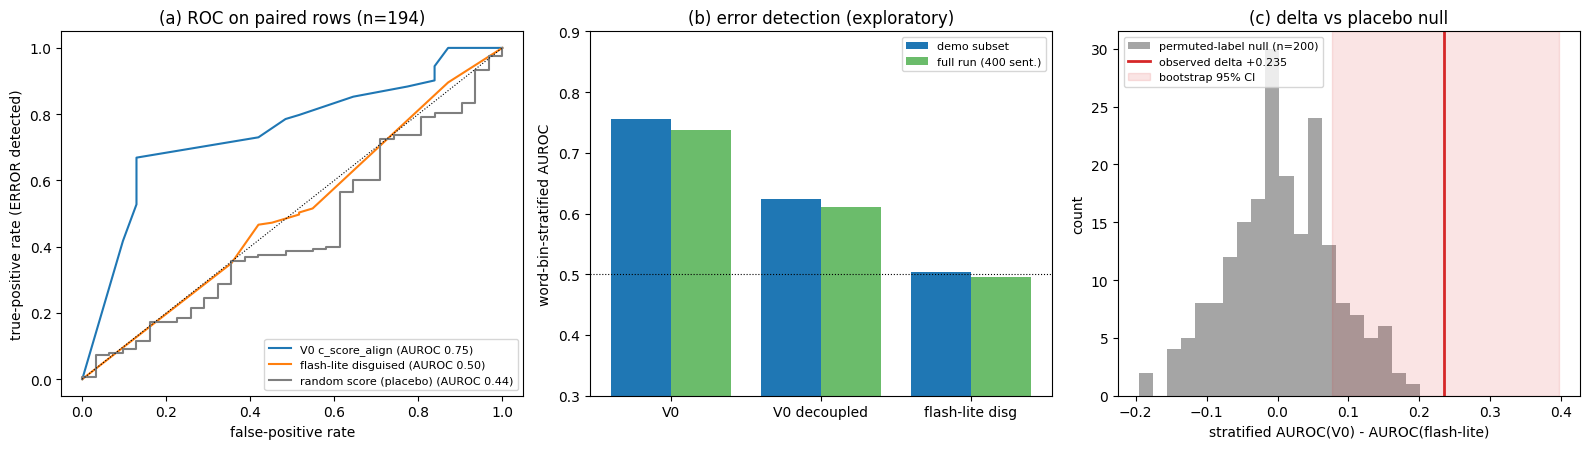

In [14]:
FULL = {  # analysis/rederive_headline.json of the full E2-B run (400 sentences)
    "V0 strat AUROC (R_A_UNAUDITED)": 0.7373, "paired n": 276, "paired n CORRECT": 31,
    "V0 AUROC (paired rows)": 0.7044, "flash-lite disg AUROC (paired rows)": 0.4961,
    "delta V0 - flash-lite": 0.2083, "delta CI low": 0.0600, "delta CI high": 0.3540,
    "permutation p (two-sided)": 0.005, "V0_decoupled strat AUROC": 0.6107,
    "Spearman(V0, flash-lite)": 0.2959, "rename flip SYN": 0.0876, "rename flip NONCE": 0.1074,
}
p, pl = out["paired"], out["placebo_permuted_labels"]
rf = out["rename_paired_flip"]
DEMO = {
    "V0 strat AUROC (R_A_UNAUDITED)": out["V0_strat_auroc"], "paired n": p["n"], "paired n CORRECT": p["n_correct"],
    "V0 AUROC (paired rows)": p["V0_auroc"], "flash-lite disg AUROC (paired rows)": p["flashlite_disg_auroc"],
    "delta V0 - flash-lite": p["delta"], "delta CI low": p["delta_ci"][0], "delta CI high": p["delta_ci"][1],
    "permutation p (two-sided)": pl["permutation_p_two_sided"], "V0_decoupled strat AUROC": out["V0_decoupled_strat_auroc"],
    "Spearman(V0, flash-lite)": out["concordance_spearman_V0_flashlite"],
    "rename flip SYN": rf.get("RENAME_SYN", {}).get("flip", float("nan")), "rename flip NONCE": rf.get("RENAME_NONCE", {}).get("flip", float("nan")),
}
print(f"{'quantity':<40}{'demo subset':>14}{'full run':>12}")
print("-" * 66)
for k in FULL:
    fmt = (lambda v: f"{v:>14d}") if isinstance(FULL[k], int) else (lambda v: f"{v:>14.3f}")
    print(f"{k:<40}{fmt(DEMO[k])}{FULL[k]:>12}")
print("\nlabel counts (demo, all LLM rows):", out["label_counts_all_llm_rows"])
print("placebo CIs include 0 as required:", pl["ci_includes_0_as_required"], out["placebo_random_score_vs_flashlite"]["ci_includes_0_as_required"])

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
# (a) ROC curves on the paired rows (positive class = ERROR)
for s_, name, col in ((a, "V0 c_score_align", "tab:blue"), (b, "flash-lite disguised", "tab:orange"), (rs, "random score (placebo)", "tab:gray")):
    fpr, tpr, _ = roc_curve(yq, s_)
    ax[0].plot(fpr, tpr, label=f"{name} (AUROC {roc_auc_score(yq, s_):.2f})", color=col)
ax[0].plot([0, 1], [0, 1], "k:", lw=0.8)
ax[0].set(xlabel="false-positive rate", ylabel="true-positive rate (ERROR detected)", title=f"(a) ROC on paired rows (n={len(Q)})")
ax[0].legend(fontsize=8, loc="lower right")
# (b) stratified AUROC: demo vs full
labels_ = ["V0", "V0 decoupled", "flash-lite disg"]
dv = [out["V0_strat_auroc"], out["V0_decoupled_strat_auroc"], p["flashlite_disg_auroc"]]
fv = [FULL["V0 strat AUROC (R_A_UNAUDITED)"], FULL["V0_decoupled strat AUROC"], FULL["flash-lite disg AUROC (paired rows)"]]
xx = np.arange(3)
ax[1].bar(xx - 0.2, dv, 0.4, label="demo subset", color="tab:blue")
ax[1].bar(xx + 0.2, fv, 0.4, label="full run (400 sent.)", color="tab:green", alpha=0.7)
ax[1].axhline(0.5, color="k", ls=":", lw=0.8)
ax[1].set_xticks(xx, labels_)
ax[1].set(ylim=(0.3, 0.9), ylabel="word-bin-stratified AUROC", title="(b) error detection (exploratory)")
ax[1].legend(fontsize=8)
# (c) permutation null vs observed delta
ax[2].hist(perm, bins=20, color="tab:gray", alpha=0.7, label=f"permuted-label null (n={len(perm)})")
ax[2].axvline(d, color="tab:red", lw=2, label=f"observed delta {d:+.3f}")
ax[2].axvspan(*p["delta_ci"], color="tab:red", alpha=0.12, label="bootstrap 95% CI")
ax[2].set(xlabel="stratified AUROC(V0) - AUROC(flash-lite)", ylabel="count", title="(c) delta vs placebo null")
ax[2].legend(fontsize=8)
plt.tight_layout()
plt.show()